In [2]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import os
import itertools
import joblib

from sklearn.preprocessing import MinMaxScaler
import keras
from keras.models import Model
from keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from pathlib import Path


2025-04-15 23:25:16.498079: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
TRAIN_FILEPATH = 'data_for_model/sound_levels_data.npy'
TEST_FILEPATH = 'data_for_model/25_event_day.npy'
SCALERS_PATH = 'scalers.pkl'
MODELS_PATH = 'models'
ONLY_INTRUSIONS = 'only_intrusions.npy'

In [4]:
def load_test_one_loc(test_path, scaler, location):

    loc = int((location - 1260)/10)
    data = np.load(test_path, allow_pickle=True)
    X_data = np.stack(data['data'], axis=0)
    X_file_names = data['filename']

    X_data = X_data[:, loc, :, :]
    shape = X_data.shape

    flat_values = X_data.reshape(-1, 1)
    X_normalised = scaler.transform(flat_values)
    X_normalised = X_normalised.reshape(shape[0], shape[1], shape[2])

    return X_normalised, X_file_names
    

In [5]:
def load_test_one_loc_intrusions(test_path, scaler, location):

    loc = int((location - 1260)/10)
    data = np.load(test_path, allow_pickle=True)
    X_data = np.stack(data['data'], axis=0)
    X_rows_poi = np.column_stack((data['row'], data['poi']))

    X_data = X_data[:, loc, :]
    shape = X_data.shape

    flat_values = X_data.reshape(-1, 1)
    X_normalised = scaler.transform(flat_values)
    X_normalised = X_normalised.reshape(shape[0], shape[1], 1)

    return X_normalised, X_rows_poi
    

In [6]:
def load_normalise_one_loc(train_path, location):

    data = np.load(train_path)

    loc = int((location - 1260)/10)
    print(loc)

    data = data[:, loc, :]
    shape = data.shape

    scaler = MinMaxScaler()

    flat_values = data.reshape(-1, 1)
    X_normalised = scaler.fit_transform(flat_values)
    X_normalised = X_normalised.reshape(shape[0], shape[1], 1)

    return X_normalised, scaler


In [7]:
def load_normalise_train_data(train_path):

    scalers = joblib.load(SCALERS_PATH)

    data = np.load(train_path)

    shape = data.shape

    num_positions = shape[1] # shape (1388, 569, 59)

    for i in range(num_positions):
        flat_values = data[:, i, :].reshape(-1, 1)
        scaled = scalers[i].transform(flat_values)
        data[:, i, :] = scaled.reshape(shape[0], shape[2])

    X_train_normalized = np.transpose(data.squeeze(), (0, 2, 1))

    return X_train_normalized

In [8]:
def variance_calculator(train_path):

    data = np.load(train_path) # 1388, 569, 59

    location_num = data.shape[1]

    for location in range(location_num):
        location_data = data[:, location, :]
        flattened_dB = location_data.flatten()
        var = np.var(flattened_dB)

        print(f"For location {location}, variance: {var}")


In [9]:
def plot_original_reconstructed(sample_idx, location, original_series, reconstructed_series, save_path=None):

    feature_idx = int((location - 1260)/10)

    original_series = original_series[sample_idx, :, feature_idx]
    reconstructed_series = reconstructed_series[sample_idx, :, feature_idx]

    plt.figure(figsize=(12, 5))
    plt.plot(original_series, label="Original", linestyle="--", marker="o", color="royalblue")
    plt.plot(reconstructed_series, label="Reconstructed", linestyle="-", marker="s", color="darkorange")

    plt.xlabel("Time Step")
    plt.ylabel("Feature Value")
    plt.ylim((0, 1))
    plt.title(f"Original vs. Reconstructed Series (Location {location})")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()  
    else:
        plt.show()

In [10]:
def try_models():

    X_train = load_normalise_train_data(TRAIN_FILEPATH)

    model_filepath = 'models/LSTM_256hu1_128hu2_0.2do_0.0005lr_mae.keras'

    model = keras.models.load_model(model_filepath)
    
    reconstructed = model.predict(X_train)

    plot_original_reconstructed(500, 4220, X_train, reconstructed)



In [11]:
def build_model(X_train_shape, hidden_units, dropout, lr, loss, activation_func):
    """Building of the model. 

    This function builds an LSTM-Autoencoder model based on the specified hyperparemeters.

    Args:
        X_train_shape (tuple): Shape of the input training data (batch_size, timesteps, features).
        hidden_units (int): Number of LSTM units in the encoder and decoder.
        dropout (float): Dropout rate to apply after LSTM layers.
        lr (float): Learning rate for the optimizer.
    loss (str): Loss function to be used for training.

    Returns:
        tensorflow.keras.Model: Compiled LSTM-Autoencoder model.
    
    """

    input_shape = (X_train_shape[1],X_train_shape[2])  # (time_steps, features)

    # Encoder
    input_seq = Input(shape=input_shape)
    encoded = LSTM(hidden_units, activation=activation_func, return_sequences=True)(input_seq) 
    encoded = LSTM(hidden_units//2, activation=activation_func, return_sequences=False)(encoded)
    encoded = Dropout(dropout)(encoded)

    # Latent space
    latent_space = Dense(hidden_units, activation='relu')(encoded)

    # Decoder
    decoded = RepeatVector(input_shape[0])(latent_space)  
    decoded = LSTM(hidden_units//2, activation=activation_func, return_sequences=True)(decoded)
    decoded = LSTM(hidden_units, activation=activation_func, return_sequences=True)(decoded)
    decoded = Dropout(dropout)(decoded)

    decoded = TimeDistributed(Dense(input_shape[1]))(decoded)

    model = Model(input_seq, decoded)

    model.compile(optimizer=Adam(learning_rate=lr), loss=loss)

    model.summary()

    return model

In [12]:
def generate_sample_data():

    # Define your desired shape
    num_samples = 1000
    timesteps = 59
    features = 1


    X_cosine = np.zeros((num_samples, timesteps, features))

    for i in range(num_samples):
        freq = np.random.uniform(0.8, 3)        # frequency variation
        phase = np.random.uniform(0, 2 * np.pi)   # phase shift variation
        noise = np.random.normal(0, 0.02, timesteps)  # small noise
        x = np.linspace(0, 2 * np.pi * freq, timesteps)
        y = np.cos(x + phase) + noise
        X_cosine[i, :, 0] = y


    X_train = 2 * np.random.rand(num_samples, timesteps, features) - 1


    return X_train

In [13]:
X_train, scaler = load_normalise_one_loc(TRAIN_FILEPATH, 4220)

296


In [13]:
model = build_model(X_train.shape, 256, 0.1, 0.0005, 'mae', 'tanh')

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

model.fit(X_train, X_train, epochs=200, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 59, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 59, 256)        │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 59, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 59, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 59, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 59, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 59, 1)          │           257 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,085,953 (4.14 MB)

 Trainable params: 1,085,953 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 508ms/step - loss: 0.0884 - val_loss: 0.0484
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 486ms/step - loss: 0.0501 - val_loss: 0.0411
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 487ms/step - loss: 0.0474 - val_loss: 0.0406
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 490ms/step - loss: 0.0452 - val_loss: 0.0396
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 489ms/step - loss: 0.0449 - val_loss: 0.0393
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 495ms/step - loss: 0.0437 - val_loss: 0.0390
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 493ms/step - loss: 0.0431 - val_loss: 0.0388
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 493ms/step - loss: 0.0427 - val_loss: 0.0388
Epoch 9/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 503ms/step - loss: 0.0434 - val_loss: 0.0396
Epoch 10/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 483ms/step - loss: 0.0427 - val_loss: 0.0387
Epoch 11/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 494ms/step - loss: 0.0425 - val_loss: 0.0385
Epoch 12/200
35/35 ━━━━━━━━━━━

In [14]:
model = keras.models.load_model("one_location_tanh.keras")

In [15]:
decoded = model.predict(X_train)

44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step


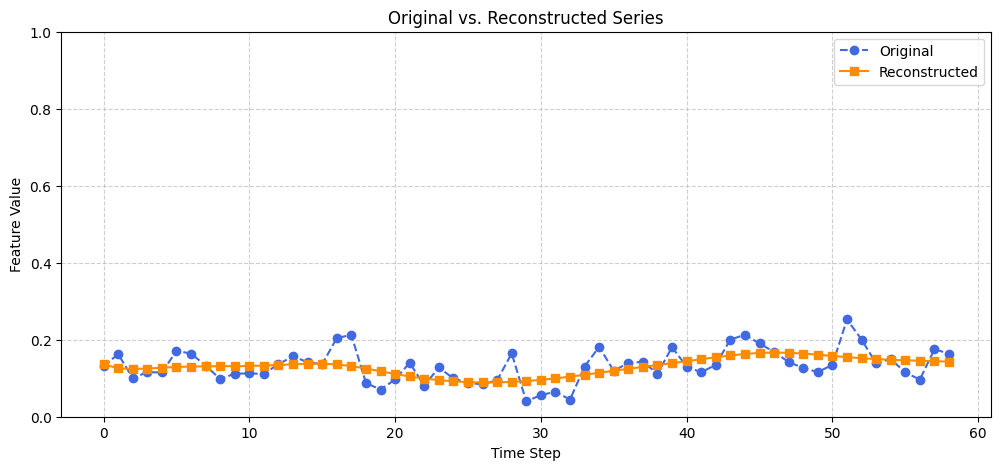

In [55]:
plt.figure(figsize=(12, 5))
plt.plot(X_train[1170, :, :], label='Original', linestyle="--", marker="o", color="royalblue")
plt.plot(decoded[1170, :, :], label="Reconstructed", linestyle="-", marker="s", color="darkorange")
plt.xlabel("Time Step")
plt.ylabel("Feature Value")
plt.title(f"Original vs. Reconstructed Series")
plt.legend()
plt.ylim((0,1))
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [16]:
train_error = np.abs(decoded - X_train)
print(np.mean(train_error), np.max(train_error), np.percentile(train_error, 99))

0.03191897088335434 0.5213477963239049 0.11887019046518327


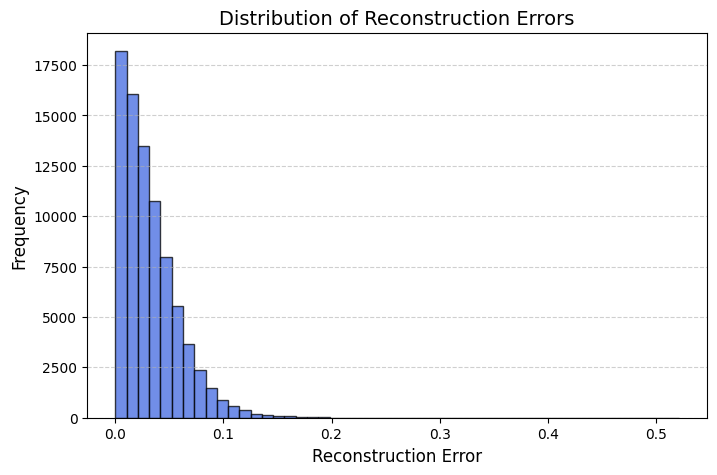

In [17]:
flat_reconstruction_error = train_error.flatten()
plt.figure(figsize=(8, 5))
plt.hist(flat_reconstruction_error, bins=50, color="royalblue", edgecolor="black", alpha=0.75)
plt.xlabel("Reconstruction Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Reconstruction Errors", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [18]:
threshold = np.max(train_error)
threshold_99 = np.percentile(train_error, 99)
midway_threshold = (threshold - threshold_99)/2

# Testing on Normal Data

In [19]:
test_data, X_test_files = load_test_one_loc(TEST_FILEPATH, scaler, 4220)
normal_test = test_data[:420, :, :]
normal_X_test_files = X_test_files[:420]

In [20]:
decoded_test_normal = model.predict(normal_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step


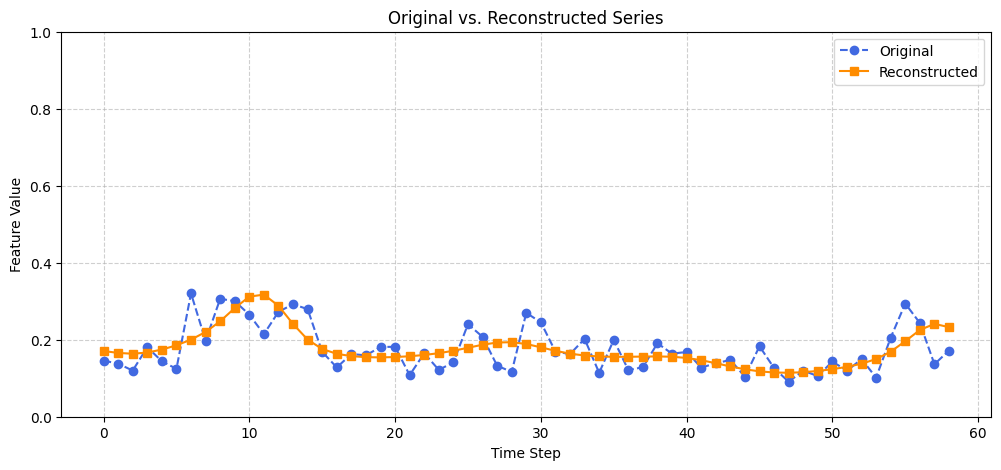

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(normal_test[400, :, :], label='Original', linestyle="--", marker="o", color="royalblue")
plt.plot(decoded_test_normal[400, :, :], label="Reconstructed", linestyle="-", marker="s", color="darkorange")
plt.xlabel("Time Step")
plt.ylabel("Feature Value")
plt.title(f"Original vs. Reconstructed Series")
plt.legend()
plt.ylim((0,1))
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [70]:
def save_anomaly_plots(original, reconstructed, sample_indices, X_test_files, save_dir, title_prefix=""):
    import os
    import matplotlib.pyplot as plt

    os.makedirs(save_dir, exist_ok=True)

    for sample in sample_indices:
        event_id = X_test_files[sample, 0]
        locations = X_test_files[sample, 1].replace(" ", "")  # Clean spacing

        # Sanitize filename (remove commas and spaces)
        safe_locations = locations.replace(",", "_")
        filename = f"{title_prefix.lower().replace(' ', '_')}_id_{event_id}_loc_{safe_locations}.png"

        # Create plot
        plt.figure(figsize=(12, 5))
        plt.plot(original[sample, :, :], label='Original', linestyle="--", marker="o", color="royalblue")
        plt.plot(reconstructed[sample, :, :], label="Reconstructed", linestyle="-", marker="s", color="darkorange")
        plt.xlabel("Time Step")
        plt.ylabel("Feature Value")
        plt.title(f"Original vs. Reconstructed Series")
        plt.legend()
        plt.ylim((0, 1))
        plt.grid(True, linestyle="--", alpha=0.6)

        # Save and close
        plt.savefig(os.path.join(save_dir, filename),  bbox_inches='tight')
        plt.close()


In [ ]:
def detect_anomalies(absolute_errors, reconstructed, original, threshold, X_test_files, plot=False):

    anomaly_idx = np.where(absolute_errors > threshold)
    print(f"With threshold {threshold}")

    if anomaly_idx[0].size == 0:
        print("No anomalies were detected.")
        return

    unique_samples = np.unique(anomaly_idx[0])
    anomalous_files = X_test_files[unique_samples]


    # Map event ID -> all sample indices where it's anomalous
    event_to_samples = {}
    event_to_locations = {}

    for idx, row in zip(unique_samples, anomalous_files):
        event_id = row[0]
        locations = [loc.strip() for loc in row[1].split(',')]
        if event_id not in event_to_samples:
            event_to_samples[event_id] = []
            event_to_locations[event_id] = set()
        event_to_samples[event_id].append(idx)
        event_to_locations[event_id].update(locations)

    total_anomalous_events = len(event_to_samples)

    
    true_positives = []
    false_positives = []
    false_positive_sample_indices = []
    for event_id, locs in event_to_locations.items():
        if '4220' in locs:
            true_positives.append(event_id)
        else:
            false_positives.append(event_id)
            false_positive_sample_indices.extend(event_to_samples[event_id])

    # ✅ Efficient ground truth for 4220 from full test set
    mask = np.char.find(X_test_files[:, 1], '4220') != -1
    ground_truth_4220_ids = np.unique(X_test_files[mask, 0])
    total_ground_truth_4220 = len(ground_truth_4220_ids)

    # Find false negatives: IDs with 4220 that were NOT flagged as anomaly
    detected_ids = set(event_to_locations.keys())
    false_negatives = [eid for eid in ground_truth_4220_ids if eid not in detected_ids]

    # Find sample indices of false negatives
    false_negative_sample_indices = []
    for i, row in enumerate(X_test_files):
        if row[0] in false_negatives:
            false_negative_sample_indices.append(i)

    # ✅ Summary
    print(f"\n🔎 Summary:")
    print(f"{total_anomalous_events} unique event IDs were flagged as anomalies.")
    print(f"{len(true_positives)} of them include location 4220 ✅ (True Positives)")
    print(f"{len(false_positives)} of them do NOT include location 4220 ❌ (False Positives)")
    print(f"{total_ground_truth_4220} total unique event IDs in the test set contain location 4220 📌 (Ground Truth)")
    print(f"{len(false_negatives)} of them were missed ❗ (False Negatives)")

    print("\n❌ False Positive Event IDs (no 4220):")
    # for eid in false_positives:
    #     print(f"- Event {eid} with locations: {', '.join(event_to_locations[eid])}")

    print("\n❗ False Negative Event IDs (should have been detected):")
    # for eid in false_negatives:
    #     print(f"- Event {eid}")


    # Step 1: Get all event IDs that have 4220
    mask_4220 = np.char.find(X_test_files[:, 1], '4220') != -1
    all_4220_event_ids = np.unique(X_test_files[mask_4220][:, 0])

    # Step 2: Event IDs detected as anomalies
    unique_samples = np.unique(anomaly_idx[0])
    detected_event_ids = np.unique(X_test_files[unique_samples][:, 0])

    # Step 3: False negative IDs = 4220 events that were never detected
    false_negative_event_ids = np.setdiff1d(all_4220_event_ids, detected_event_ids)

    # Step 4: Get sample indices belonging to these false negative IDs
    false_negative_sample_indices = np.where(np.isin(X_test_files[:, 0], false_negative_event_ids))[0]

    print(false_negative_event_ids)

    # print("\n📍 Sample indices of False Positives:")
    # print(false_positive_sample_indices)

    # print("\n📍 Sample indices of False Negatives:")
    # print(false_negative_sample_indices)

    # Save false positive plots
    # save_anomaly_plots(
    #     original,
    #     reconstructed,
    #     false_positive_sample_indices,
    #     X_test_files,
    #     save_dir="plots/false_positives",
    #     title_prefix="False Positive"
    # )

    # # Save false negative plots
    # save_anomaly_plots(
    #     original,
    #     reconstructed,
    #     false_negative_sample_indices,
    #     X_test_files,
    #     save_dir="plots/false_negatives",
    #     title_prefix="False Negative"
    # )

In [23]:
normal_test_error = abs(normal_test - decoded_test_normal)
print(np.mean(normal_test_error), np.max(normal_test_error), np.percentile(normal_test_error, 99))

0.02806461387698347 0.22870700480104256 0.09840247613783705


In [ ]:
normal_test_error = abs(normal_test - decoded_test_normal)
plt.figure(figsize=(8, 5))
plt.hist(normal_test_error.flatten(), bins=50, color="royalblue", edgecolor="black", alpha=0.75)
plt.xlabel("Reconstruction Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Reconstruction Errors", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [56]:
detect_anomalies(normal_test_error, decoded_test_normal, normal_test, threshold, normal_X_test_files)

With threshold 0.5213477963239049
No anomalies were detected.


# Baseline Approach: Normal Data

In [26]:
anomalies_idx = np.where(normal_test > 1)
[len(a) for a in anomalies_idx]

[0, 0, 0]

# Testing on Event Data

In [27]:
intrusion_test_data, event_row = load_test_one_loc_intrusions(ONLY_INTRUSIONS, scaler, 4220)

In [28]:
decoded_test_intrusion = model.predict(intrusion_test_data)

46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step


In [29]:
intrusion_test_error = abs(intrusion_test_data - decoded_test_intrusion)
print(np.mean(intrusion_test_error), np.max(intrusion_test_error), np.percentile(intrusion_test_error, 99))

0.05600545846144416 0.8585604393164805 0.4167773279105753


In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(intrusion_test_error.flatten(), bins=50, color="royalblue", edgecolor="black", alpha=0.75)
plt.xlabel("Reconstruction Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Reconstruction Errors", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [77]:
detect_anomalies(intrusion_test_error, decoded_test_intrusion, intrusion_test_data, threshold_99, event_row)

With threshold 0.11887019046518327

🔎 Summary:
365 unique event IDs were flagged as anomalies.
302 of them include location 4220 ✅ (True Positives)
63 of them do NOT include location 4220 ❌ (False Positives)
331 total unique event IDs in the test set contain location 4220 📌 (Ground Truth)
29 of them were missed ❗ (False Negatives)

❌ False Positive Event IDs (no 4220):

❗ False Negative Event IDs (should have been detected):
['107' '110' '120' '128' '160' '161' '182' '200' '201' '206' '210' '212'
 '227' '228' '229' '275' '276' '279' '280' '371' '372' '374' '377' '378'
 '379' '388' '389' '390' '402']


# Baseline Approach: Intrusion Data

In [45]:
counter = 0
for row in event_row:
    poi = np.array([int(x.strip()) for x in row[1].split(",")]) 
    if 4220 in poi:
        counter = counter + 1

print(counter)

1275


In [46]:
mask = np.char.find(event_row[:, 1], '4220') != -1

# Get unique IDs from the first column where 4220 appears
unique_ids = np.unique(event_row[mask, 0])
len(unique_ids)

331

In [47]:
anomalies_idx_intrusions = np.where(intrusion_test_data > 1)
[len(a) for a in anomalies_idx_intrusions]

[183, 183, 183]

In [48]:
unique_anomalies_samples = np.unique(anomalies_idx_intrusions[0])
unique_events = np.unique(event_row[unique_anomalies_samples])
print(len(unique_anomalies_samples), len(unique_events))


54 31


In [51]:
event_row[unique_anomalies_samples]

array([['287', '4210, 4220, 4230, 4240, 4250 ,4260'],
       ['288', '4210, 4220, 4230, 4240, 4250 ,4260'],
       ['289', '4210, 4220, 4230, 4240, 4250 ,4260'],
       ['290', '4210, 4220, 4230, 4240, 4250 ,4260'],
       ['291', '4210, 4220, 4230, 4240, 4250 ,4260'],
       ['292', '4220, 4230, 4240'],
       ['292', '4220, 4230, 4240'],
       ['292', '4220, 4230, 4240'],
       ['292', '4220, 4230, 4240'],
       ['292', '4220, 4230, 4240'],
       ['292', '4220, 4230, 4240'],
       ['292', '4220, 4230, 4240'],
       ['292', '4220, 4230, 4240'],
       ['292', '4220, 4230, 4240'],
       ['292', '4220, 4230, 4240'],
       ['292', '4220, 4230, 4240'],
       ['293', '4210, 4220, 4230, 4240, 4250 ,4260'],
       ['293', '4210, 4220, 4230, 4240, 4250 ,4260'],
       ['293', '4210, 4220, 4230, 4240, 4250 ,4260'],
       ['294', '4210, 4220, 4230, 4240, 4250 ,4260'],
       ['295', '4210, 4220, 4230, 4240, 4250 ,4260'],
       ['296', '4210, 4220, 4230, 4240, 4250 ,4260'],
       ['2

In [ ]:
event_row

(1468, 2)

# Junk

In [ ]:
def load_normalise_per_loc_and_hour(filepath):

    # loading sound level data; shape (1388, 689, 59, 1)
    data = np.load(filepath)

    position_indices = np.arange(689)
    values = 60 + 10 * position_indices  

    valid_positions = np.where(values >= 1260)[0]

    reshaped_data = data[:, valid_positions, :, :]  

    num_positions = reshaped_data.shape[1] 
    num_timesteps = reshaped_data.shape[2] 
    num_samples = reshaped_data.shape[0]  

    scalers_per_hour = {hour: {} for hour in range(24)}
    flag = False

    for hour in range(24): 
        for loc in range(num_positions):  
           
            start_idx = hour * 60  
            end_idx = (hour + 1) * 60  

            if end_idx > 1388:
                data_hour_location = reshaped_data[start_idx:, loc, :, 0].reshape(-1, 1)  
                flag = True
            else:
                data_hour_location = reshaped_data[start_idx:end_idx, loc, :, 0].reshape(-1, 1) 

            scaler = MinMaxScaler()
            scaled = scaler.fit_transform(data_hour_location)
            
            if flag:
                reshaped_data[start_idx:, loc, :, 0] = scaled.reshape((60, num_timesteps))
                flag = False
            else: 
                reshaped_data[start_idx:end_idx, loc, :, 0] = scaled.reshape((60, num_timesteps))

            scalers_per_hour[hour][loc] = scaler

    X_train_normalized = reshaped_data.squeeze().transpose(0, 2, 1)

    joblib.dump(scalers_per_hour, 'scalers_per_hour.pkl')

    return X_train_normalized